# EXPERIMENT-5: POS Tagging, Chunking and Parsing

**Aim**

1. Categorize and tag words in Twitter data.
2. Implement POS tagging and chunking for sentences.
3. Demonstrate shallow parsing and dependency parsing.

**Dataset:** Kaggle Twitter Tweets Sentiment Dataset (`Tweets.csv`).

In [1]:
# Install required packages
!pip -q install pandas matplotlib seaborn nltk spacy kagglehub
!python -m spacy download en_core_web_sm

     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
     ----- ---------------------------------- 1.8/12.8 MB 10.1 MB/s eta 0:00:02
     ------------- -------------------------- 4.2/12.8 MB 11.0 MB/s eta 0:00:01
     ------------------ --------------------- 5.8/12.8 MB 9.8 MB/s eta 0:00:01
     -------------------- ------------------- 6.6/12.8 MB 8.2 MB/s eta 0:00:01
     --------------------- ------------------ 6.8/12.8 MB 7.5 MB/s eta 0:00:01
     ---------------------- ----------------- 7.3/12.8 MB 6.1 MB/s eta 0:00:01
     ------------------------ --------------- 7.9/12.8 MB 5.5 MB/s eta 0:00:01
     --------------------------- ------------ 8.7/12.8 MB 5.2 MB/s eta 0:00:01
     ----------------------------- ---------- 9.4/12.8 MB 5.1 MB/s eta 0:00:01
     -------------------------------- ------- 10.5/12.8 MB 5.0 MB/s eta 0:00:01
     ----------------------------------- ---- 11.3/12.8 MB 4.9 MB/s eta 0:00:01
     -------------------------------------- - 12.3/12.8

In [2]:
import os
import glob
from collections import Counter

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
import kagglehub
import spacy

from nltk.tokenize import word_tokenize, TweetTokenizer
from nltk import pos_tag, RegexpParser

# Download NLTK resources required by current NLTK versions
resources = [
    "punkt",
    "punkt_tab",
    "averaged_perceptron_tagger",
    "averaged_perceptron_tagger_eng"
]

for resource in resources:
    nltk.download(resource, quiet=True)

print("Libraries and NLTK resources loaded successfully.")

d:\anaconda\envs\pytorch-gpu\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Libraries and NLTK resources loaded successfully.


## 1. Download and Load the Kaggle Dataset

In [3]:
path = kagglehub.dataset_download("yasserh/twitter-tweets-sentiment-dataset")

csv_files = glob.glob(os.path.join(path, "**", "*.csv"), recursive=True)

print("Dataset location:", path)
print("\nCSV files found:")
for f in csv_files:
    print("-", f)

if not csv_files:
    raise FileNotFoundError("No CSV file found.")

tweet_file = next(
    (f for f in csv_files if os.path.basename(f).lower() == "tweets.csv"),
    csv_files[0]
)

df = pd.read_csv(tweet_file)

print("\nUsing file:", tweet_file)
print("Dataset shape:", df.shape)
display(df.head())

100%|██████████| 1.23M/1.23M [00:01<00:00, 746kB/s]

Extracting files...
Dataset location: C:\Users\hp\.cache\kagglehub\datasets\yasserh\twitter-tweets-sentiment-dataset\versions\1

CSV files found:
- C:\Users\hp\.cache\kagglehub\datasets\yasserh\twitter-tweets-sentiment-dataset\versions\1\Tweets.csv

Using file: C:\Users\hp\.cache\kagglehub\datasets\yasserh\twitter-tweets-sentiment-dataset\versions\1\Tweets.csv
Dataset shape: (27481, 4)


,textID,text,selected_text,sentiment
0,cb774db0d1,"I`d have responded, if I were going","I`d have responded, if I were going",neutral
1,549e992a42,Sooo SAD I will miss you here in San Diego!!!,Sooo SAD,negative
2,088c60f138,my boss is bullying me...,bullying me,negative
3,9642c003ef,what interview! leave me alone,leave me alone,negative
4,358bd9e861,"Sons of ****, why couldn`t they put them on t...","Sons of ****,",negative


## 2. Understand the Dataset

In [4]:
print("Columns:")
print(list(df.columns))

print("\nMissing values:")
display(df.isnull().sum())

print("\nData types:")
display(df.dtypes)

Columns:
['textID', 'text', 'selected_text', 'sentiment']

Missing values:


textID           0
text             1
selected_text    1
sentiment        0
dtype: int64


Data types:


textID           object
text             object
selected_text    object
sentiment        object
dtype: object

In [5]:
# Select the tweet/text column explicitly when available.
# The Kaggle dataset normally contains a column named text.
if "text" in df.columns:
    TEXT_COLUMN = "text"
else:
    candidates = [
        c for c in df.columns
        if any(k in c.lower() for k in ["text", "tweet", "content", "message"])
    ]
    if not candidates:
        raise ValueError("Could not identify the tweet/text column.")
    TEXT_COLUMN = candidates[0]

df[TEXT_COLUMN] = df[TEXT_COLUMN].fillna("").astype(str)
df = df[df[TEXT_COLUMN].str.strip().ne("")].reset_index(drop=True)

print("Selected text column:", TEXT_COLUMN)
print("Usable tweets:", len(df))
display(df[[TEXT_COLUMN]].head(10))

Selected text column: text
Usable tweets: 27480


,text
0,"I`d have responded, if I were going"
1,Sooo SAD I will miss you here in San Diego!!!
2,my boss is bullying me...
3,what interview! leave me alone
4,"Sons of ****, why couldn`t they put them on t..."
5,http://www.dothebouncy.com/smf - some shameles...
6,2am feedings for the baby are fun when he is a...
7,Soooo high
8,Both of you
9,Journey!? Wow... u just became cooler. hehe....


## 3. Inspect Twitter Text

Twitter data may contain hashtags, mentions, URLs, punctuation, emojis and informal language.

In [6]:
sample_tweets = df[TEXT_COLUMN].sample(min(10, len(df)), random_state=42).tolist()

print("Sample Twitter data:\n")
for i, tweet in enumerate(sample_tweets, 1):
    print(f"{i}. {tweet}")

Sample Twitter data:

1.  Enjoy! Family trumps everything
2.  --of them kinda turns me off of it all.  And then I buy more of them and dig a deeper hole, etc. ;;
3. Clive it`s my birthday pat me  http://apps.facebook.com/dogbook/profile/view/6386106
4.  congrats hey
5. is texting
6.  Do you have any idea when the (not so) patient fans will see some teaser pics of you all in costume?
7.  Tell him where...
8.  Ooooh, I`m jealous  I might try and get some for the saturday but I have an exam on the monday that Im gonna fail
9.  OHSHNAPSSS. is she pissed at blair as usual ? hahah. & yeeeah, i bake cookies
10. wee. done with advance audit paper


## 4. Twitter Tokenization

`TweetTokenizer` is designed for social-media text and is therefore more appropriate than a simple whitespace split.

In [7]:
tweet_tokenizer = TweetTokenizer(
    preserve_case=True,
    reduce_len=True,
    strip_handles=False
)

example_tweet = sample_tweets[0]
tokens = tweet_tokenizer.tokenize(example_tweet)

print("Tweet:")
print(example_tweet)

print("\nTokens:")
print(tokens)

Tweet:
 Enjoy! Family trumps everything

Tokens:
['Enjoy', '!', 'Family', 'trumps', 'everything']


## 5. POS Tagging of a Sentence

POS tagging assigns a grammatical category to each token.

Common Penn Treebank tags:

- NN — noun
- VB — verb
- JJ — adjective
- RB — adverb
- PRP — personal pronoun
- DT — determiner

In [8]:
sentence = "The students are learning natural language processing today."

tokens = word_tokenize(sentence)
tags = pos_tag(tokens)

print("Sentence:", sentence)
print("\nPOS Tags:")
print(f"{'Word':20} {'POS Tag'}")
print("-" * 30)

for word, tag in tags:
    print(f"{word:20} {tag}")

Sentence: The students are learning natural language processing today.

POS Tags:
Word                 POS Tag
------------------------------
The                  DT
students             NNS
are                  VBP
learning             VBG
natural              JJ
language             NN
processing           NN
today                NN
.                    .


### Expected output

```text
The                  DT
students             NNS
are                  VBP
learning             VBG
natural              JJ
language             NN
processing           NN
today                NN
.                    .
```

Exact output can vary slightly with the installed NLTK model version.

## 6. POS Tagging on Twitter Data

In [9]:
N_TWEETS = min(500, len(df))
twitter_sample = df.sample(N_TWEETS, random_state=42).copy()

def twitter_pos_tag(text):
    tokens = tweet_tokenizer.tokenize(text)
    return pos_tag(tokens)

twitter_sample["tokens"] = twitter_sample[TEXT_COLUMN].apply(
    tweet_tokenizer.tokenize
)

twitter_sample["pos_tags"] = twitter_sample[TEXT_COLUMN].apply(
    twitter_pos_tag
)

print(f"POS tagging completed for {N_TWEETS} tweets.")
display(twitter_sample[[TEXT_COLUMN, "tokens", "pos_tags"]].head(10))

POS tagging completed for 500 tweets.


,text,tokens,pos_tags
1588,Enjoy! Family trumps everything,"[Enjoy, !, Family, trumps, everything]","[(Enjoy, NN), (!, .), (Family, NNP), (trumps, ..."
10413,--of them kinda turns me off of it all. And ...,"[-, -, of, them, kinda, turns, me, off, of, it...","[(-, :), (-, :), (of, IN), (them, PRP), (kinda..."
6561,Clive it`s my birthday pat me http://apps.fac...,"[Clive, it, `, s, my, birthday, pat, me, http:...","[(Clive, JJ), (it, PRP), (`, ``), (s, VB), (my..."
2602,congrats hey,"[congrats, hey]","[(congrats, NNS), (hey, VBP)]"
4003,is texting,"[is, texting]","[(is, VBZ), (texting, VBG)]"
1569,Do you have any idea when the (not so) patien...,"[Do, you, have, any, idea, when, the, (, not, ...","[(Do, VBP), (you, PRP), (have, VBP), (any, DT)..."
27231,Tell him where...,"[Tell, him, where, ...]","[(Tell, NNP), (him, PRP), (where, WRB), (..., :)]"
8285,"Ooooh, I`m jealous I might try and get some ...","[Ooooh, ,, I, `, m, jealous, I, might, try, an...","[(Ooooh, NNP), (,, ,), (I, PRP), (`, ``), (m, ..."
579,OHSHNAPSSS. is she pissed at blair as usual ?...,"[OHSHNAPSSS, ., is, she, pissed, at, blair, as...","[(OHSHNAPSSS, NNP), (., .), (is, VBZ), (she, P..."
9188,wee. done with advance audit paper,"[wee, ., done, with, advance, audit, paper]","[(wee, NN), (., .), (done, VBN), (with, IN), (..."


## 7. Categorize POS Tags in Twitter Data

In [10]:
all_tags = []

for tagged_sentence in twitter_sample["pos_tags"]:
    all_tags.extend(tag for _, tag in tagged_sentence)

tag_counts = Counter(all_tags)

tag_df = (
    pd.DataFrame(
        tag_counts.items(),
        columns=["POS_Tag", "Frequency"]
    )
    .sort_values("Frequency", ascending=False)
    .reset_index(drop=True)
)

print("Top POS tags:")
display(tag_df.head(20))

Top POS tags:


,POS_Tag,Frequency
0,NN,1279
1,.,572
2,PRP,551
3,IN,550
4,JJ,543
5,NNP,486
6,RB,453
7,DT,425
8,VB,389
9,VBP,293


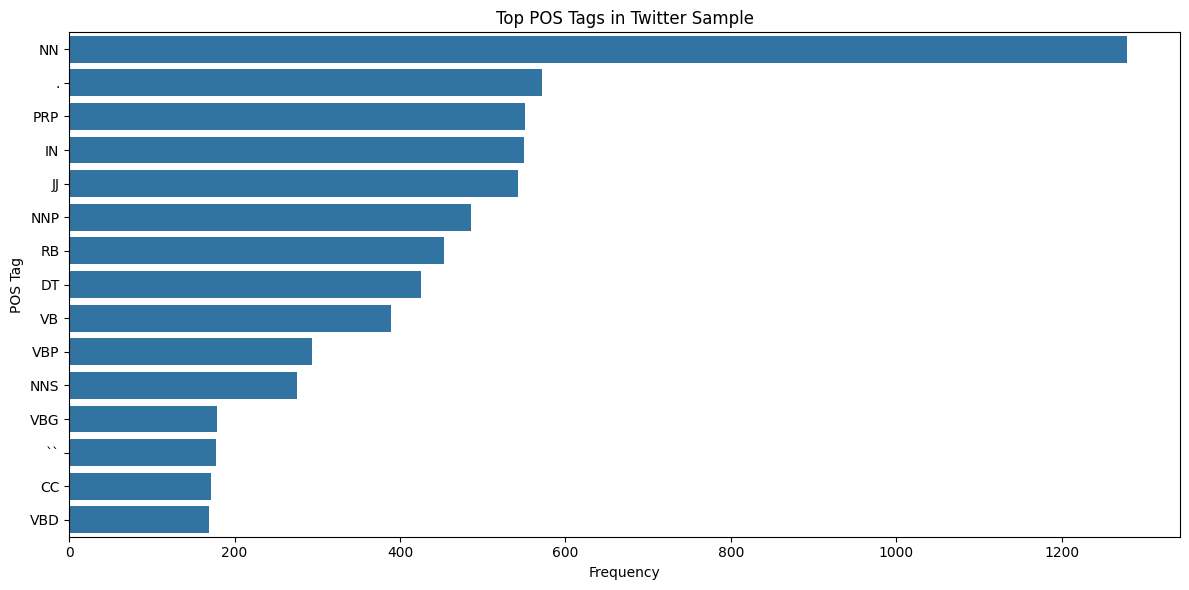

In [11]:
plt.figure(figsize=(12, 6))
sns.barplot(
    data=tag_df.head(15),
    x="Frequency",
    y="POS_Tag"
)
plt.title("Top POS Tags in Twitter Sample")
plt.xlabel("Frequency")
plt.ylabel("POS Tag")
plt.tight_layout()
plt.show()

## 8. Broad POS Categories

In [12]:
def broad_category(tag):
    if tag.startswith("NN"):
        return "Noun"
    if tag.startswith("VB"):
        return "Verb"
    if tag.startswith("JJ"):
        return "Adjective"
    if tag.startswith("RB") or tag == "WRB":
        return "Adverb"
    if tag in {"PRP", "WP"}:
        return "Pronoun"
    if tag in {"PRP$", "WP$"}:
        return "Possessive Pronoun"
    if tag in {"DT", "PDT", "WDT"}:
        return "Determiner"
    if tag in {"IN", "TO"}:
        return "Preposition/Subordinator"
    if tag == "CC":
        return "Conjunction"
    if tag == "CD":
        return "Number"
    if tag == "MD":
        return "Modal"
    if tag == "UH":
        return "Interjection"
    if tag == "RP":
        return "Particle"
    if tag == "POS":
        return "Possessive"
    if tag == "SYM":
        return "Symbol"
    if tag in {".", ",", ":", "``", "''", "-LRB-", "-RRB-"}:
        return "Punctuation"
    return "Other"

category_counts = Counter(
    broad_category(tag)
    for tag in all_tags
)

category_df = (
    pd.DataFrame(
        category_counts.items(),
        columns=["Category", "Frequency"]
    )
    .sort_values("Frequency", ascending=False)
    .reset_index(drop=True)
)

display(category_df)

,Category,Frequency
0,Noun,2043
1,Verb,1260
2,Punctuation,1076
3,Preposition/Subordinator,716
4,Pronoun,578
5,Adjective,575
6,Adverb,513
7,Determiner,446
8,Conjunction,171
9,Possessive Pronoun,142


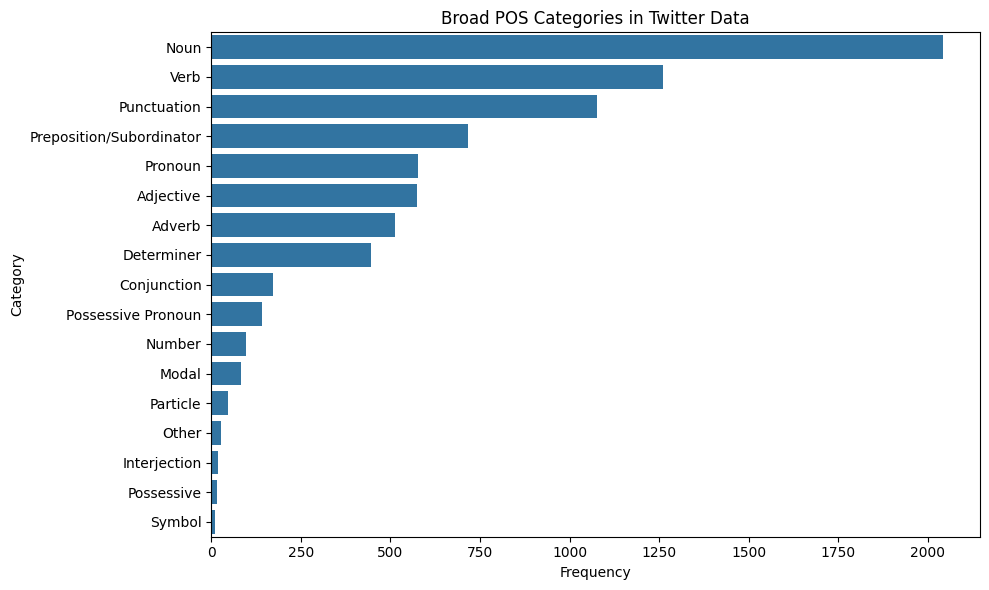

In [13]:
plt.figure(figsize=(10, 6))
sns.barplot(
    data=category_df,
    x="Frequency",
    y="Category"
)
plt.title("Broad POS Categories in Twitter Data")
plt.xlabel("Frequency")
plt.ylabel("Category")
plt.tight_layout()
plt.show()

## 9. POS Tagging and Dependency Parsing with spaCy

In [14]:
nlp = spacy.load("en_core_web_sm")

test_sentence = (
    "The intelligent student solved the difficult NLP problem quickly."
)

doc = nlp(test_sentence)

print(f"{'Token':15} {'POS':10} {'Tag':10} {'Dependency':15} {'Head':15}")
print("-" * 70)

for token in doc:
    print(
        f"{token.text:15} "
        f"{token.pos_:10} "
        f"{token.tag_:10} "
        f"{token.dep_:15} "
        f"{token.head.text:15}"
    )

Token           POS        Tag        Dependency      Head           
----------------------------------------------------------------------
The             DET        DT         det             student        
intelligent     ADJ        JJ         amod            student        
student         NOUN       NN         nsubj           solved         
solved          VERB       VBD        ROOT            solved         
the             DET        DT         det             problem        
difficult       ADJ        JJ         amod            problem        
NLP             PROPN      NNP        compound        problem        
problem         NOUN       NN         dobj            solved         
quickly         ADV        RB         advmod          solved         
.               PUNCT      .          punct           solved         


## 10. Chunking / Shallow Parsing

Chunking groups words into meaningful phrases.

The grammar below identifies:

- **NP** — Noun Phrase
- **VP** — Verb Phrase
- **PP** — Prepositional Phrase

In [15]:
# Improved chunk grammar
chunk_grammar = r'''
    NP: {<DT|PRP\$>?<JJ.*>*<NN.*>+}
    NP: {<NNP>+}
    VP: {<MD>?<VB.*>(<RB.*>)*}
    PP: {<IN|TO><NP>}
'''

chunk_parser = RegexpParser(chunk_grammar)

chunk_sentence = (
    "The intelligent student solved the difficult NLP problem "
    "in the laboratory."
)

chunk_tokens = word_tokenize(chunk_sentence)
chunk_tagged = pos_tag(chunk_tokens)
chunk_tree = chunk_parser.parse(chunk_tagged)

print("Sentence:")
print(chunk_sentence)

print("\nPOS tagged sentence:")
print(chunk_tagged)

print("\nChunked structure:")
print(chunk_tree)

Sentence:
The intelligent student solved the difficult NLP problem in the laboratory.

POS tagged sentence:
[('The', 'DT'), ('intelligent', 'JJ'), ('student', 'NN'), ('solved', 'VBD'), ('the', 'DT'), ('difficult', 'JJ'), ('NLP', 'NNP'), ('problem', 'NN'), ('in', 'IN'), ('the', 'DT'), ('laboratory', 'NN'), ('.', '.')]

Chunked structure:
(S
  (NP The/DT intelligent/JJ student/NN)
  (VP solved/VBD)
  (NP the/DT difficult/JJ NLP/NNP problem/NN)
  (PP in/IN (NP the/DT laboratory/NN))
  ./.)


### Expected chunk interpretation

The important phrase-level structures should include approximately:

- **NP:** The intelligent student
- **NP:** the difficult NLP problem
- **PP:** in the laboratory

The exact tree representation depends on the NLTK POS tagger version.

In [16]:
print("Extracted Noun Phrases:")
print("-" * 35)

for subtree in chunk_tree.subtrees(
    filter=lambda t: t.label() == "NP"
):
    phrase = " ".join(word for word, tag in subtree.leaves())
    print("NP:", phrase)

Extracted Noun Phrases:
-----------------------------------
NP: The intelligent student
NP: the difficult NLP problem
NP: the laboratory


## 11. Chunking a Twitter-Style Sentence

In [17]:
twitter_sentence = (
    "The new AI model is really amazing for image classification!"
)

twitter_tagged = pos_tag(
    tweet_tokenizer.tokenize(twitter_sentence)
)

twitter_tree = chunk_parser.parse(twitter_tagged)

print("Tweet:")
print(twitter_sentence)

print("\nPOS Tags:")
print(twitter_tagged)

print("\nChunks:")
print(twitter_tree)

print("\nExtracted Noun Phrases:")
for subtree in twitter_tree.subtrees(
    filter=lambda t: t.label() == "NP"
):
    print("NP:", " ".join(word for word, tag in subtree.leaves()))

Tweet:
The new AI model is really amazing for image classification!

POS Tags:
[('The', 'DT'), ('new', 'JJ'), ('AI', 'NNP'), ('model', 'NN'), ('is', 'VBZ'), ('really', 'RB'), ('amazing', 'JJ'), ('for', 'IN'), ('image', 'NN'), ('classification', 'NN'), ('!', '.')]

Chunks:
(S
  (NP The/DT new/JJ AI/NNP model/NN)
  (VP is/VBZ really/RB)
  amazing/JJ
  (PP for/IN (NP image/NN classification/NN))
  !/.)

Extracted Noun Phrases:
NP: The new AI model
NP: image classification


## 12. Dependency Parsing

In [18]:
dependency_sentence = (
    "The researcher developed a new NLP model for Twitter data."
)

dependency_doc = nlp(dependency_sentence)

print(f"{'Token':15} {'POS':10} {'Dependency':15} {'Head':15}")
print("-" * 60)

for token in dependency_doc:
    print(
        f"{token.text:15} "
        f"{token.pos_:10} "
        f"{token.dep_:15} "
        f"{token.head.text:15}"
    )

Token           POS        Dependency      Head           
------------------------------------------------------------
The             DET        det             researcher     
researcher      NOUN       nsubj           developed      
developed       VERB       ROOT            developed      
a               DET        det             model          
new             ADJ        amod            model          
NLP             PROPN      compound        model          
model           NOUN       dobj            developed      
for             ADP        prep            model          
Twitter         PROPN      compound        data           
data            NOUN       pobj            for            
.               PUNCT      punct           developed      


## 13. Visualize Dependency Parse

In [19]:
from spacy import displacy

displacy.render(
    dependency_doc,
    style="dep",
    jupyter=True,
    options={"distance": 100}
)

## 14. POS Tagging of Multiple Twitter Samples

In [20]:
print("POS tagging of five Twitter samples:\n")

for i, tweet in enumerate(
    twitter_sample[TEXT_COLUMN].head(5), 1
):
    print(f"Tweet {i}:")
    print(tweet)
    print("Tags:", twitter_pos_tag(tweet))
    print("-" * 80)

POS tagging of five Twitter samples:

Tweet 1:
 Enjoy! Family trumps everything
Tags: [('Enjoy', 'NN'), ('!', '.'), ('Family', 'NNP'), ('trumps', 'VBD'), ('everything', 'NN')]
--------------------------------------------------------------------------------
Tweet 2:
 --of them kinda turns me off of it all.  And then I buy more of them and dig a deeper hole, etc. ;;
Tags: [('-', ':'), ('-', ':'), ('of', 'IN'), ('them', 'PRP'), ('kinda', 'FW'), ('turns', 'VBZ'), ('me', 'PRP'), ('off', 'IN'), ('of', 'IN'), ('it', 'PRP'), ('all', 'DT'), ('.', '.'), ('And', 'CC'), ('then', 'RB'), ('I', 'PRP'), ('buy', 'VBP'), ('more', 'JJR'), ('of', 'IN'), ('them', 'PRP'), ('and', 'CC'), ('dig', 'VB'), ('a', 'DT'), ('deeper', 'JJR'), ('hole', 'NN'), (',', ','), ('etc', 'FW'), ('.', '.'), (';', ':'), (';', ':')]
--------------------------------------------------------------------------------
Tweet 3:
Clive it`s my birthday pat me  http://apps.facebook.com/dogbook/profile/view/6386106
Tags: [('Clive', 'JJ'), (

## 15. Experiment Observations

1. POS tagging assigns grammatical categories to individual tokens.
2. Twitter text is noisy because it may contain hashtags, mentions, URLs, emojis and informal spellings.
3. `TweetTokenizer` is suitable for social-media text.
4. NLTK provides POS tagging and grammar-based chunking.
5. Chunking identifies shallow phrase structures such as noun phrases and prepositional phrases.
6. spaCy provides POS tagging together with dependency relations and visualization.
7. POS taggers trained on standard English may be less accurate on informal Twitter language.

## 16. Result

POS tagging was successfully applied to Twitter data. The experiment also demonstrated tokenization, POS-tag frequency analysis, broad grammatical categorization, chunking/shallow parsing and dependency parsing.

The notebook uses the Kaggle Twitter dataset for real-world Twitter text and controlled sentences for demonstrating phrase and dependency structures.